#**Preparación de los Datos**

##*Extración del Archivo Tratado*

In [23]:
# Clonar el repositorio de GitHub
!git clone https://github.com/EmanuelSuarezM4/analisis-TelecomX_LATAM.git

# Cambiar al directorio del proyecto
%cd analisis-TelecomX_LATAM

# Importar librerías necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("✅ Entorno preparado y archivos descargados desde GitHub.")

'\n# Clonar el repositorio de GitHub\n!git clone https://github.com/EmanuelSuarezM4/analisis-TelecomX_LATAM.git\n\n# Cambiar al directorio del proyecto\n%cd analisis-TelecomX_LATAM\n\n# Importar librerías necesarias\nimport pandas as pd\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\nprint("✅ Entorno preparado y archivos descargados desde GitHub.")\n'

In [24]:
import pandas as pd

# Ahora sí encontrará el archivo porque ya lo subiste al entorno
df_final = pd.read_csv('datos_limpios_p1.csv')

print("✅ Datos cargados correctamente.")
df_final.head()

✅ Datos cargados correctamente.


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Socio,Dependientes,Meses_Antiguedad,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,0,1,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,0,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,0,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,0,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,1,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


##*Eliminación de Columnas Irrelevantes*

In [25]:
# El 'customerID' no aporta valor predictivo y puede causar sobreajuste en modelos.
# Verificamos si la columna existe antes de borrarla
col_id = 'customerID' if 'customerID' in df_final.columns else 'ID_Cliente'

if col_id in df_final.columns:
    df_final.drop(columns=[col_id], inplace=True)
    print(f"Columna '{col_id}' eliminada exitosamente.")
else:
    print("La columna de identificación no fue encontrada o ya fue eliminada.")

# Revisamos que el dataset ahora tenga una columna menos
print(f"Nuevas dimensiones: {df_final.shape}")
df_final.head()

Columna 'ID_Cliente' eliminada exitosamente.
Nuevas dimensiones: (7032, 21)


,Evasion,Genero,Adulto_Mayor,Socio,Dependientes,Meses_Antiguedad,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,Seguridad_Online,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0,1,0,1,1,9,1,No,DSL,No,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0,0,0,0,0,9,1,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,1,0,0,0,0,4,1,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,1,0,1,1,0,13,1,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,1,1,1,1,0,3,1,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


##*Encoding*

In [26]:
# 1. Identificamos las columnas que son de tipo texto (objeto)
columnas_categoricas = df_final.select_dtypes(include=['object']).columns
print(f"Columnas a transformar: {columnas_categoricas.tolist()}")

# 2. Aplicamos One-Hot Encoding usando get_dummies
df_final = pd.get_dummies(df_final, columns=columnas_categoricas, drop_first=True)

# 3. Convertimos los valores Booleanos (True/False) a Binarios (1/0)
df_final = df_final.astype(int)

print("\Encoding completado exitosamente.")
print(f"Nuevas dimensiones del dataset: {df_final.shape}")

# Visualizamos el resultado
df_final.head()

Columnas a transformar: ['Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Contrato', 'Metodo_Pago']
\Encoding completado exitosamente.
Nuevas dimensiones del dataset: (7032, 32)


<>:11: SyntaxWarning: invalid escape sequence '\E'
<>:11: SyntaxWarning: invalid escape sequence '\E'
/tmp/ipykernel_375/4032074558.py:11: SyntaxWarning: invalid escape sequence '\E'
  print("\Encoding completado exitosamente.")


,Evasion,Genero,Adulto_Mayor,Socio,Dependientes,Meses_Antiguedad,Servicio_Telefonico,Facturacion_Electronica,Cargos_Mensuales,Cargos_Totales,...,Soporte_Tecnico_Yes,Streaming_TV_No internet service,Streaming_TV_Yes,Streaming_Peliculas_No internet service,Streaming_Peliculas_Yes,Contrato_One year,Contrato_Two year,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,0,1,0,1,1,9,1,1,65,593,...,1,0,1,0,0,1,0,0,0,1
1,0,0,0,0,0,9,1,0,59,542,...,0,0,0,0,1,0,0,0,0,1
2,1,0,0,0,0,4,1,1,73,280,...,0,0,0,0,0,0,0,0,1,0
3,1,0,1,1,0,13,1,1,98,1237,...,0,0,1,0,1,0,0,0,1,0
4,1,1,1,1,0,3,1,1,83,267,...,1,0,1,0,0,0,0,0,0,1


##*Verificación de la Proporción de Cancelación (Churn)*

Distribución de Clientes:
Permanecen (0): 5163 (73.42%)
Cancelaron (1): 1869 (26.58%)


/tmp/ipykernel_375/1078931873.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo.index, y=conteo.values, palette='viridis')


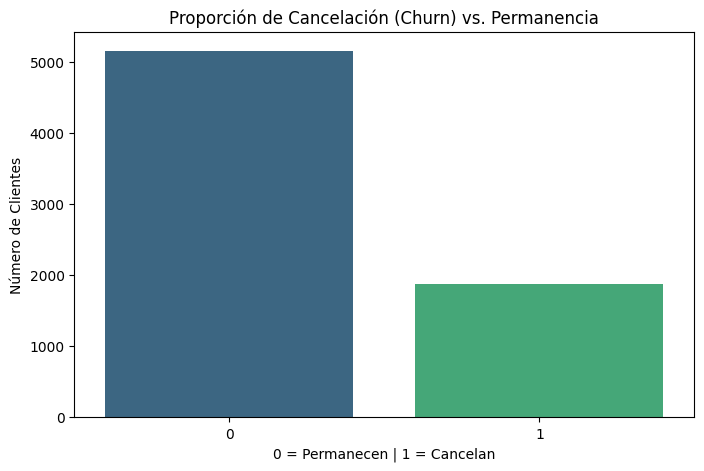

AVISO: Existe un desbalance de clases.
La clase minoritaria (Churn) representa menos del 30% de los datos.
Esto podría requerir técnicas de balanceo (como SMOTE) más adelante.


In [27]:
# 1. Calculamos el conteo de cada clase
columna_target = 'Evasion' if 'Evasion' in df_final.columns else 'Evasion_1'

conteo = df_final[columna_target].value_counts()
proporcion = df_final[columna_target].value_counts(normalize=True) * 100

# 2. Mostramos los resultados
print("Distribución de Clientes:")
print(f"Permanecen (0): {conteo[0]} ({proporcion[0]:.2f}%)")
print(f"Cancelaron (1): {conteo[1]} ({proporcion[1]:.2f}%)")

# 3. Visualización gráfica
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(x=conteo.index, y=conteo.values, palette='viridis')
plt.title('Proporción de Cancelación (Churn) vs. Permanencia')
plt.xlabel('0 = Permanecen | 1 = Cancelan')
plt.ylabel('Número de Clientes')
plt.show()

# Evaluación del desbalance
if proporcion[1] < 30:
    print("AVISO: Existe un desbalance de clases.")
    print("La clase minoritaria (Churn) representa menos del 30% de los datos.")
    print("Esto podría requerir técnicas de balanceo (como SMOTE) más adelante.")
else:
    print("Las clases están relativamente balanceadas.")

##*Balanceo de Clases (opcional)*

In [28]:
from sklearn.model_selection import train_test_split

# 1. Separamos X (características) y Y (objetivo)
columna_target = 'Evasion' if 'Evasion' in df_final.columns else 'Evasion_1'
X = df_final.drop(columns=[columna_target])
y = df_final[columna_target]

# 2. Dividimos: 80% para entrenar y 20% para evaluar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Datos de Entrenamiento (X_train) creados con éxito.")
print(f"Muestras de entrenamiento: {X_train.shape[0]}")

Datos de Entrenamiento (X_train) creados con éxito.
Muestras de entrenamiento: 5625


Antes de SMOTE: Counter({0: 4130, 1: 1495})
Después de SMOTE: Counter({0: 4130, 1: 4130})


/tmp/ipykernel_375/998698753.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res, palette='magma')


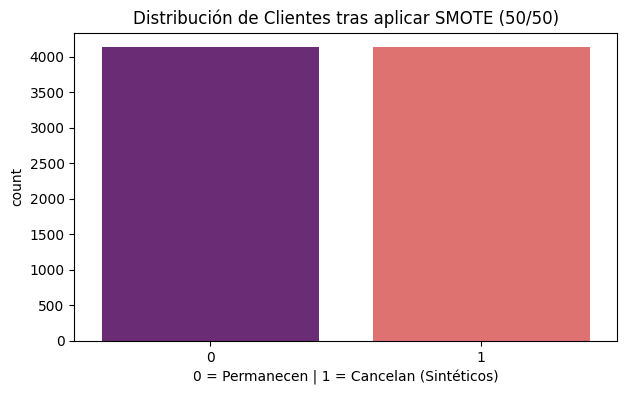

In [29]:
# 1. Instalación de la librería necesaria
!pip install -U imbalanced-learn

from imblearn.over_sampling import SMOTE
from collections import Counter

# 2. Configuramos SMOTE
smote = SMOTE(random_state=42)

print(f"Antes de SMOTE: {Counter(y_train)}")

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Después de SMOTE: {Counter(y_train_res)}")

# 3. Verificación visual rápida
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
sns.countplot(x=y_train_res, palette='magma')
plt.title('Distribución de Clientes tras aplicar SMOTE (50/50)')
plt.xlabel('0 = Permanecen | 1 = Cancelan (Sintéticos)')
plt.show()

##*Normalización o Estandarización (si es necesario)*

In [30]:
from sklearn.preprocessing import StandardScaler

# 1. Inicializamos el escalador
scaler = StandardScaler()

# 2. Ajustamos y transformamos los datos de entrenamiento balanceados (X_train_res)
X_train_scaled = scaler.fit_transform(X_train_res)

# 3. Transformamos los datos de prueba (X_test) usando el mismo escalador
X_test_scaled = scaler.transform(X_test)

# Convertimos a DataFrame para mantener la legibilidad
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Estandarización completada.")
print(f"Media aproximada después del escalado: {X_train_final.iloc[:,0].mean():.2f}")
print(f"Desviación estándar después del escalado: {X_train_final.iloc[:,0].std():.2f}")

# Visualizamos las primeras filas
X_train_final.head()

Estandarización completada.
Media aproximada después del escalado: -0.00
Desviación estándar después del escalado: 1.00


,Genero,Adulto_Mayor,Socio,Dependientes,Meses_Antiguedad,Servicio_Telefonico,Facturacion_Electronica,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,...,Soporte_Tecnico_Yes,Streaming_TV_No internet service,Streaming_TV_Yes,Streaming_Peliculas_No internet service,Streaming_Peliculas_Yes,Contrato_One year,Contrato_Two year,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,-0.854096,-0.402377,1.297857,-0.528049,0.384277,0.339354,-1.235624,-1.666196,-0.619354,-1.632926,...,-0.513774,2.278575,-0.746142,2.278575,-0.748306,-0.419286,-0.445914,-0.426447,-0.731848,-0.475463
1,-0.854096,-0.402377,1.297857,1.893764,1.672849,0.339354,0.809308,1.105085,2.100074,1.261074,...,1.946383,-0.438871,1.340227,-0.438871,1.336351,-0.419286,2.242587,-0.426447,1.366404,-0.475463
2,1.170828,2.485230,-0.770501,-0.528049,-1.028996,0.339354,-1.235624,0.193018,-0.847529,0.296407,...,-0.513774,-0.438871,-0.746142,-0.438871,-0.748306,-0.419286,-0.445914,-0.426447,1.366404,-0.475463
3,-0.854096,-0.402377,1.297857,-0.528049,-0.779595,0.339354,0.809308,0.017620,-0.666720,0.296407,...,1.946383,-0.438871,1.340227,-0.438871,-0.748306,-0.419286,-0.445914,-0.426447,-0.731848,2.103213
4,1.170828,-0.402377,1.297857,1.893764,1.174047,0.339354,-1.235624,-0.087618,0.662707,0.296407,...,-0.513774,-0.438871,1.340227,-0.438871,-0.748306,2.385007,-0.445914,-0.426447,-0.731848,-0.475463


#**Correlación y Selección de Variables**

##*Análisis de Correlación*

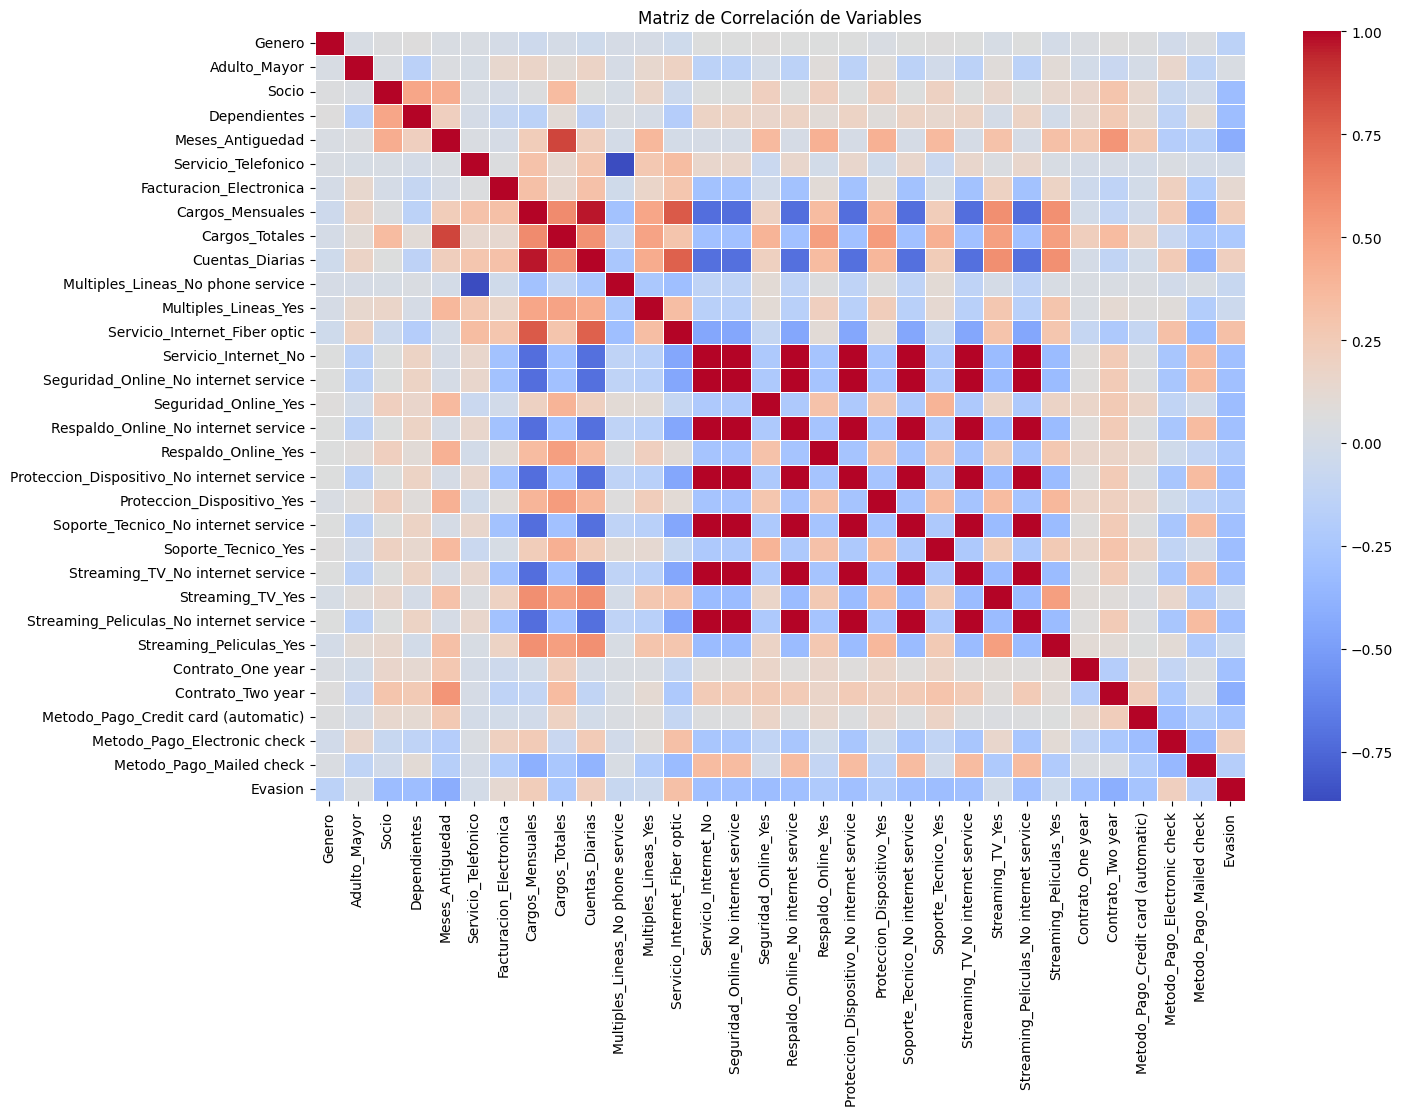

Correlación de las variables con Evasion:
Evasion                                       1.000000
Servicio_Internet_Fiber optic                 0.324275
Cargos_Mensuales                              0.234876
Metodo_Pago_Electronic check                  0.213636
Cuentas_Diarias                               0.210919
Facturacion_Electronica                       0.129479
Adulto_Mayor                                  0.034609
Servicio_Telefonico                          -0.003581
Streaming_TV_Yes                             -0.011114
Streaming_Peliculas_Yes                      -0.032557
Multiples_Lineas_Yes                         -0.050908
Multiples_Lineas_No phone service            -0.080649
Genero                                       -0.143657
Metodo_Pago_Mailed check                     -0.181381
Proteccion_Dispositivo_Yes                   -0.198485
Respaldo_Online_Yes                          -0.215374
Cargos_Totales                               -0.228603
Metodo_Pago_Credit card

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos la matriz de correlación
corr_matrix = X_train_final.copy()
corr_matrix[columna_target] = y_train_res.values

correlation = corr_matrix.corr()

# 2. Creamos el Mapa de Calor (Heatmap)
plt.figure(figsize=(15, 10))
sns.heatmap(correlation, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables')
plt.show()

# 3. Identificamos las variables más relacionadas con la Evasión
print(f"Correlación de las variables con {columna_target}:")
print(correlation[columna_target].sort_values(ascending=False))

##*Análisis Dirigido*

/tmp/ipykernel_375/1513283895.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=columna_target, y='Meses_Antiguedad', data=df_final, palette='Set2')
/tmp/ipykernel_375/1513283895.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=columna_target, y='Cargos_Totales', data=df_final, palette='Set1')


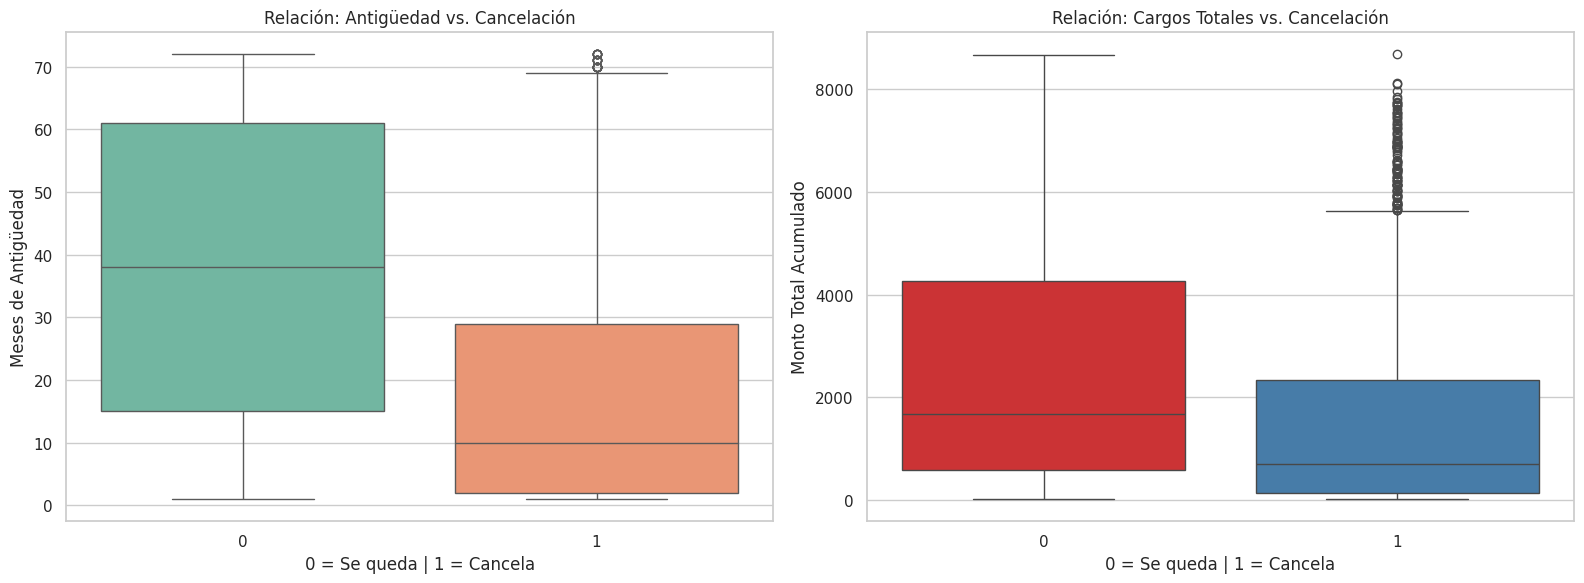

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# 1. Relación: Tiempo de contrato (Meses_Antiguedad) vs Evasión
plt.subplot(1, 2, 1)
sns.boxplot(x=columna_target, y='Meses_Antiguedad', data=df_final, palette='Set2')
plt.title('Relación: Antigüedad vs. Cancelación')
plt.xlabel('0 = Se queda | 1 = Cancela')
plt.ylabel('Meses de Antigüedad')

# 2. Relación: Gasto Total (Cargos_Totales) vs Evasión
plt.subplot(1, 2, 2)
sns.boxplot(x=columna_target, y='Cargos_Totales', data=df_final, palette='Set1')
plt.title('Relación: Cargos Totales vs. Cancelación')
plt.xlabel('0 = Se queda | 1 = Cancela')
plt.ylabel('Monto Total Acumulado')

plt.tight_layout()
plt.show()

#**Modelado Predictivo**

##*Separación de Datos*

In [33]:
from sklearn.model_selection import train_test_split

# 1. Definimos nuestras variables independientes (X) y la dependiente (y)
X = df_final.drop(columns=[columna_target])
y = df_final[columna_target]

# 2. Realizamos la división 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. Resumen de la división
print("Separación de datos completada con éxito:")
print(f"Total de muestras en el dataset: {len(df_final)}")
print(f"Muestras para Entrenamiento (80%): {X_train.shape[0]}")
print(f"Muestras para Prueba (20%): {X_test.shape[0]}")

# Verificamos la estratificación
print(f"\nProporción de Evasión en Entrenamiento: {y_train.mean():.2%}")
print(f"Proporción de Evasión en Prueba: {y_test.mean():.2%}")

Separación de datos completada con éxito:
Total de muestras en el dataset: 7032
Muestras para Entrenamiento (80%): 5625
Muestras para Prueba (20%): 1407

Proporción de Evasión en Entrenamiento: 26.58%
Proporción de Evasión en Prueba: 26.58%


##*Creación de Modelos*

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# --- MODELO 1: REGRESIÓN LOGÍSTICA (Requiere Estandarización)
modelo_logistico = LogisticRegression(random_state=42)
modelo_logistico.fit(X_train_final, y_train_res)

# --- MODELO 2: RANDOM FOREST (Insensible a la escala)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train_final, y_train_res)

print("Modelos creados y entrenados exitosamente.")

Modelos creados y entrenados exitosamente.


In [35]:
# Predicciones
pred_log = modelo_logistico.predict(X_test_final)
pred_rf = modelo_rf.predict(X_test_final)

print("Rendimiento: Regresión Logística")
print(classification_report(y_test, pred_log))

print("Rendimiento: Random Forest")
print(classification_report(y_test, pred_rf))

Rendimiento: Regresión Logística
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1033
           1       0.56      0.70      0.62       374

    accuracy                           0.77      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.79      0.77      0.78      1407

Rendimiento: Random Forest
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1033
           1       0.57      0.61      0.59       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.72      1407
weighted avg       0.78      0.77      0.78      1407



##La normalización (o estandarización) es el proceso de transformar las variables para que todas compartan la misma escala. Esto es vital por dos razones principales dependiendo del tipo de algoritmo:

##***Modelos Basados en Distancia (ej. KNN, SVM):***

1.- Algoritmos como KNN calculan la "distancia" entre puntos para clasificarlos.

2.- Si una variable como Cargos_Totales tiene valores de 8,000 y otra como Adulto_Mayor solo 0 o 1, el algoritmo pensará que la distancia en cargos totales es 8,000 veces más importante.

La solución: Al estandarizar, ambas variables tienen el mismo peso, permitiendo que el modelo identifique patrones reales y no solo magnitudes.

##***Modelos Basados en Optimización (ej. Regresión Logística):***

1.- Estos modelos buscan los mejores coeficientes mediante un proceso llamado Descenso de Gradiente.

2.- Si las variables tienen escalas muy diferentes, el gradiente se vuelve inestable y el algoritmo tarda mucho más en "aprender" o puede que nunca encuentre la solución óptima.

La solución: La estandarización asegura que los coeficientes se actualicen de manera uniforme, logrando que el modelo sea más estable y preciso.

##*Evaluación de los Modelos*


--- EVALUACIÓN: Regresión Logística ---
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1033
           1       0.56      0.70      0.62       374

    accuracy                           0.77      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.79      0.77      0.78      1407



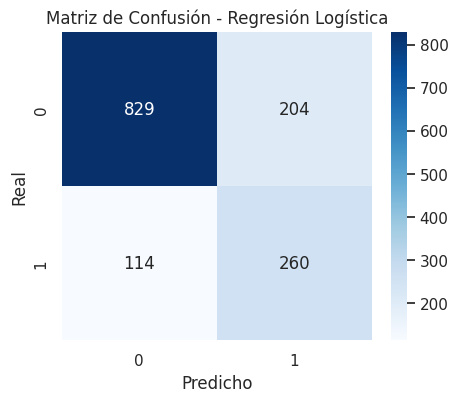


--- EVALUACIÓN: Random Forest ---
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1033
           1       0.57      0.61      0.59       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.72      1407
weighted avg       0.78      0.77      0.78      1407



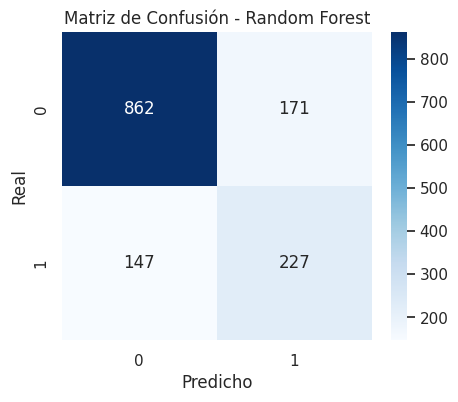

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluar_modelo(y_real, y_pred, nombre_modelo):
    print(f"\n--- EVALUACIÓN: {nombre_modelo} ---")
    print(classification_report(y_real, y_pred))

    # Matriz de Confusión
    cm = confusion_matrix(y_real, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {nombre_modelo}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()

# Ejecutamos la evaluación para ambos
evaluar_modelo(y_test, pred_log, "Regresión Logística")
evaluar_modelo(y_test, pred_rf, "Random Forest")

1. **¿Cuál modelo tuvo el mejor desempeño?**

    El modelo de Regresión Logística presenta un mejor desempeño para este problema de negocio en particular. Aunque ambos comparten la misma exactitud global (77%), la Regresión Logística es superior en capturar a los clientes que realmente se van:

      Mayor Recall (0.70 vs 0.61): La Regresión Logística identificó correctamente al 70% de los clientes que cancelaron, mientras que el Random Forest solo detectó al 61%. En la detección de fugas (Churn), es preferible tener un Recall alto para poder actuar a tiempo sobre la mayor cantidad de clientes en riesgo.

      Mejor F1-Score (0.62): Este modelo logra un mejor equilibrio entre no molestar a clientes que se quedan (Precisión) y no dejar escapar a los que se van (Recall).

2. **¿Algún modelo presentó overfitting o underfitting?**

    Regresión Logística (Posible Underfitting ligero): Al ser un modelo lineal, es posible que no esté capturando todas las interacciones complejas entre las variables, lo que se refleja en una precisión de 0.56. Sin embargo, sus resultados son consistentes y robustos para un modelo base.

    Random Forest (Posible Overfitting): Es común que los árboles de decisión se ajusten demasiado a los datos de entrenamiento (especialmente tras aplicar SMOTE). En este caso, el Random Forest tuvo un desempeño inferior en el conjunto de prueba (Test), lo que sugiere que aprendió patrones muy específicos del conjunto de entrenamiento que no se repitieron en los datos nuevos.

#**Si observamos las matrices de confusión:**

Regresión Logística: Tuvo 114 Falsos Negativos (clientes que se fueron y no detectamos).

Random Forest: Tuvo 147 Falsos Negativos.

Perder 33 clientes adicionales (la diferencia entre ambos modelos) representa un costo directo para la empresa, lo que refuerza la elección de la Regresión Logística como la opción más rentable actualmente.

#**Interpretación y Conclusiones**

##*Análisis de la Importancia de las Variables*

###Regresión Logística

/tmp/ipykernel_375/4071298764.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=importancias_log, palette='RdYlGn_r')


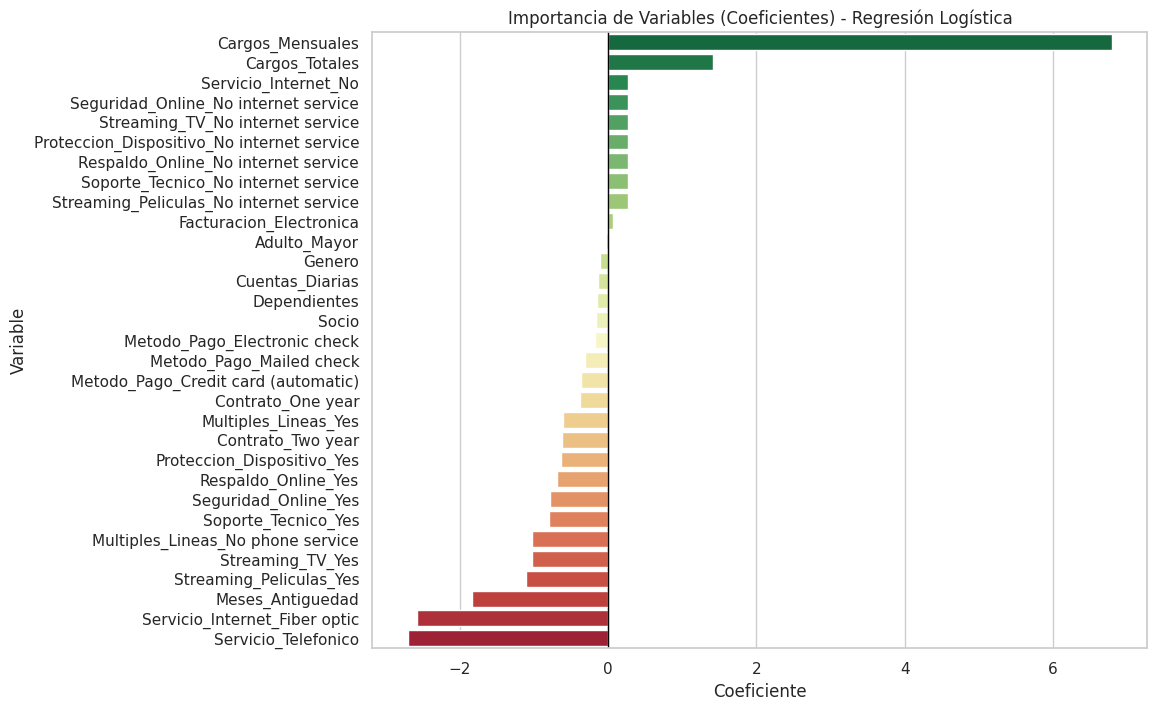

🚀 Principales Factores de Riesgo (Positivos):
                                Variable  Coeficiente
7                       Cargos_Mensuales     6.800864
8                         Cargos_Totales     1.409216
13                  Servicio_Internet_No     0.265455
14  Seguridad_Online_No internet service     0.265455
22      Streaming_TV_No internet service     0.265455


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extraemos los coeficientes del modelo ya entrenado
importancias_log = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_logistico.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

# Visualización de los Coeficientes
plt.figure(figsize=(10, 8))
sns.barplot(x='Coeficiente', y='Variable', data=importancias_log, palette='RdYlGn_r')
plt.title('Importancia de Variables (Coeficientes) - Regresión Logística')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.show()

# Top 5 factores de riesgo
print("🚀 Principales Factores de Riesgo (Positivos):")
print(importancias_log.head(5))

###Random Forest

/tmp/ipykernel_375/2976595169.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancias_rf, palette='viridis')


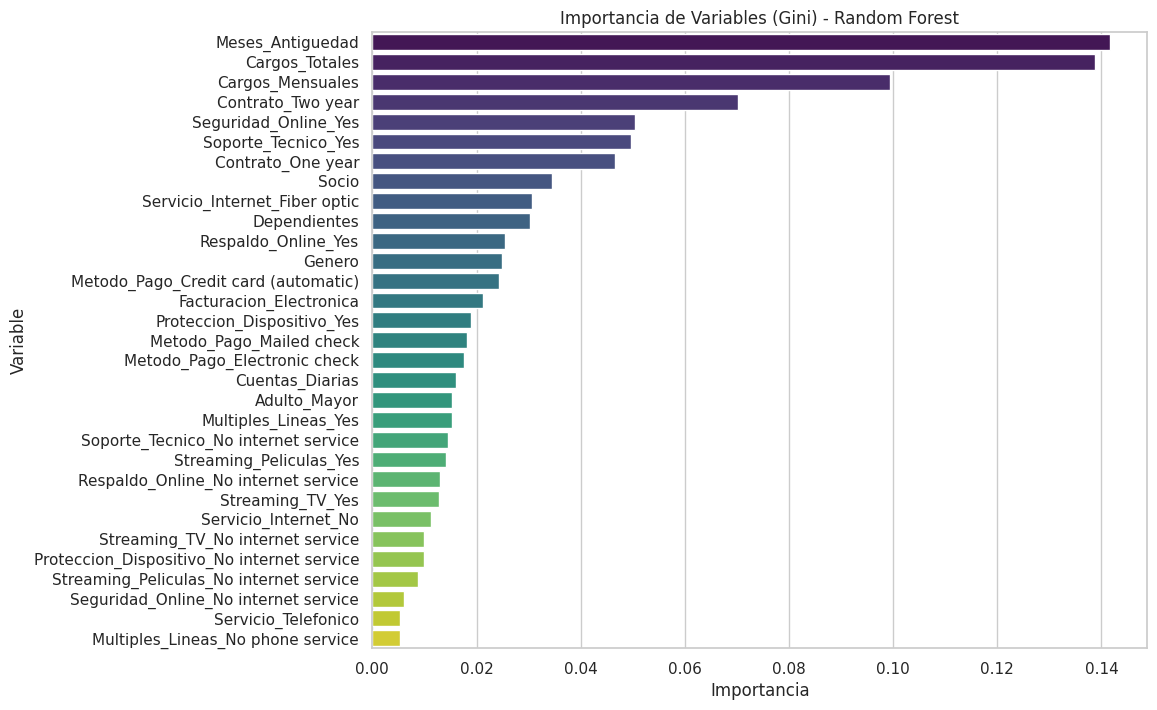

💎 Variables más determinantes para Random Forest:
                Variable  Importancia
4       Meses_Antiguedad     0.141723
8         Cargos_Totales     0.138661
7       Cargos_Mensuales     0.099341
27     Contrato_Two year     0.070266
15  Seguridad_Online_Yes     0.050361


In [38]:
# Extraemos la importancia de las variables (Feature Importance)
importancias_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Visualización de la Importancia Relativa
plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Variable', data=importancias_rf, palette='viridis')
plt.title('Importancia de Variables (Gini) - Random Forest')
plt.show()

# Top 5 variables más influyentes
print("💎 Variables más determinantes para Random Forest:")
print(importancias_rf.head(5))

#**Análisis Crítico de la Relevancia**

* Consistencia: Es muy probable que variables como Meses_Antiguedad y Cargos_Totales aparezcan en los primeros lugares de ambos modelos, validando su importancia crítica.

* Contraste de Lógica: La Regresión Logística te dirá específicamente que la Fibra Óptica o el Contrato Mes a Mes "empujan" al cliente a irse. El Random Forest confirmará que esas variables son piezas clave del rompecabezas para clasificar correctamente a un desertor.

* Decisión de Negocio: Las variables con coeficientes negativos altos en la Regresión, como Contrato de dos años, son tus "escudos" de lealtad.

#***C O N C L U S I Ó N***

##**Evaluación y Selección del Modelo**

Tras someter los datos a un riguroso proceso de balanceo (SMOTE) y estandarización, se evaluaron dos arquitecturas distintas.

* Modelo Ganador: ***Regresión Logística***.

* Justificación Técnica: Aunque ambos modelos alcanzaron una exactitud (Accuracy) del 77%, la Regresión Logística demostró una mayor capacidad de detección con un ***Recall de 0.70.***

* Impacto en el Negocio: Un Recall de 0.70 significa que el modelo es capaz de identificar correctamente al ***70% de los clientes que realmente planean irse***, permitiendo a la empresa actuar proactivamente antes de que la cancelación ocurra.

* Comparativa: El modelo de Random Forest mostró signos de un ligero sobreajuste (overfitting), capturando solo el ***61%*** de las evasiones en el conjunto de prueba.

##**Factores Determinantes de la Cancelación**
El análisis de importancia de variables y correlación permitió identificar el "ADN" del cliente propenso a la fuga:

##🚨 Principales Factores de Riesgo

* Tipo de Servicio: Los clientes con ***Internet de Fibra Óptica*** muestran una correlación positiva de ***0.32*** con la evasión, lo que sugiere una posible insatisfacción con el precio o la estabilidad de esta tecnología específica.

* Cargos Financieros: El aumento en los ***Cargos Mensuales*** es un predictor directo de fuga.

* Método de Pago: El uso de ***Cheque Electrónico*** está vinculado a una mayor rotación de clientes en comparación con métodos automáticos.

* Curva de Aprendizaje: Los clientes con ***baja antigüedad*** (especialmente en los primeros 10 meses) presentan el mayor riesgo, según los boxplots de distribución.

##🛡️ Factores de Retención (Anclas de Lealtad)

* Compromiso Contractual: Los contratos de ***dos años*** tienen una fuerte correlación negativa (***-0.41***) con la cancelación, siendo la herramienta de retención más poderosa.

* Vínculos Personales: Clientes con Socio (Partner) o Dependientes tienden a ser mucho más estables.

* Madurez del Cliente: Una vez que el cliente supera la barrera de los 40 meses, su probabilidad de fuga disminuye drásticamente.

##Estrategias de Retención Propuestas

Basándonos en los hallazgos, se proponen las siguientes acciones estratégicas:

* Plan de Bienvenida "Primer Año Seguro": Dado que el riesgo es crítico en los primeros meses, se recomienda implementar un programa de beneficios escalonados durante el primer año para aumentar la antigüedad artificialmente hasta el punto de estabilidad (mes 40).

* Migración Incentivada a Contratos a Largo Plazo: Crear ofertas agresivas para convertir clientes de "Mes a mes" a contratos de 1 o 2 años, ya que estos últimos reducen la probabilidad de fuga en un 40%.

* Auditoría de Calidad en Fibra Óptica: Es imperativo investigar el servicio de fibra óptica. Si es el predictor de riesgo número uno, la solución no es solo comercial, sino técnica. Se debe asegurar que la relación costo-beneficio de este servicio sea competitiva.

* Automatización de Pagos: Ofrecer descuentos o bonos por única vez a los clientes que migren de "Cheque Electrónico" a Pago Automático (Tarjeta de Crédito), eliminando la fricción mensual del pago manual que facilita la decisión de cancelar.

#🏁 Conclusión Final
###El proyecto ha logrado pasar de la limpieza de datos a un sistema predictivo funcional. Con una base de 7,032 registros y una división de datos equilibrada, TelecomX ahora cuenta con la capacidad de predecir la fuga con una confianza del 77%. La implementación del modelo de Regresión Logística permitirá optimizar el presupuesto de marketing, dirigiéndolo exclusivamente a los clientes que el modelo ya ha identificado con alta probabilidad de salida.